# Analisis de insights de la industria musical con Spotify Charts

Este cuaderno deja atras la auditoria superficial y se enfoca en preguntas que si pueden producir observaciones utiles sobre la industria musical.

Preguntas centrales:
- Que tan concentrado esta el liderazgo del chart en pocos artistas.
- Que tan globales son los artistas dominantes frente a los lideres locales.
- Que tan estable o volatil es el Top 10 de artistas.
- Si las posiciones altas tienden a estar ocupadas por artistas ya consolidados.
- Que sellos dominan el chart de albumes.
- Que tan rapido entran los albumes al chart despues de su lanzamiento.
- Si un debut fuerte se relaciona con una mayor permanencia.


## 1. Librerias y configuracion

In [27]:
from __future__ import annotations

from pathlib import Path
import warnings

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.ticker import PercentFormatter

from pyspark.sql import SparkSession
from pyspark.sql import functions as F

warnings.filterwarnings('ignore')

sns.set_theme(style='whitegrid', context='talk')
plt.rcParams['figure.figsize'] = (14, 8)
plt.rcParams['axes.titlesize'] = 18
plt.rcParams['axes.labelsize'] = 13
plt.rcParams['xtick.labelsize'] = 11
plt.rcParams['ytick.labelsize'] = 11


In [28]:
RAIZ = Path.cwd().resolve().parent if Path.cwd().name == 'notebooks' else Path.cwd().resolve() / 'spotify_project'
if RAIZ.name != 'spotify_project':
    RAIZ = Path.cwd().resolve() / 'spotify_project'

DIR_RAW = RAIZ / 'raw'
DIR_OUTPUTS = RAIZ / 'outputs'
DIR_OUTPUTS.mkdir(parents=True, exist_ok=True)

ARCHIVOS_ESPERADOS = {
    'charts_artists_daily': DIR_RAW / 'charts_artists_daily.csv',
    'charts_albums_weekly': DIR_RAW / 'charts_albums_weekly.csv',
}

for nombre, ruta in ARCHIVOS_ESPERADOS.items():
    print(nombre, '->', ruta.exists(), ruta)


charts_artists_daily -> True /Users/armand501/Library/Mobile Documents/com~apple~CloudDocs/My Documents/Maestria/Análisis de grandes volúmenes de datos/spotify_project/raw/charts_artists_daily.csv
charts_albums_weekly -> True /Users/armand501/Library/Mobile Documents/com~apple~CloudDocs/My Documents/Maestria/Análisis de grandes volúmenes de datos/spotify_project/raw/charts_albums_weekly.csv


In [29]:
spark = (
    SparkSession.builder.master('local[*]')
    .appName('spotify-charts-insights')
    .config('spark.sql.session.timeZone', 'America/Mexico_City')
    .config('spark.sql.shuffle.partitions', '4')
    .config('spark.default.parallelism', '4')
    .config('spark.sql.adaptive.enabled', 'true')
    .getOrCreate()
)
spark


## 2. Funciones auxiliares para limpieza segura

Estas funciones evitan que el notebook falle cuando el dataset trae fechas o enteros mal formados.

In [30]:
def entero_seguro(nombre_columna: str):
    return F.when(
        F.col(nombre_columna).cast('string').rlike(r'^-?\d+$'),
        F.col(nombre_columna).cast('int')
    )


def fecha_segura(nombre_columna: str):
    return F.when(
        F.col(nombre_columna).cast('string').rlike(r'^\d{4}-\d{2}-\d{2}$'),
        F.to_date(F.col(nombre_columna))
    )


def banda_rank(columna_rank: str):
    return (
        F.when(F.col(columna_rank) <= 10, '1-10')
        .when(F.col(columna_rank) <= 25, '11-25')
        .when(F.col(columna_rank) <= 50, '26-50')
        .when(F.col(columna_rank) <= 100, '51-100')
        .otherwise('101-200')
    )


ORDEN_BANDAS = ['1-10', '11-25', '26-50', '51-100', '101-200']
ORDEN_LAG = ['0-7', '8-30', '31-180', '181-365', '366-3650']


## 3. Carga y limpieza de artistas y albumes

In [31]:
ruta_artistas = ARCHIVOS_ESPERADOS['charts_artists_daily']
ruta_albumes = ARCHIVOS_ESPERADOS['charts_albums_weekly']

if not ruta_artistas.exists() or not ruta_albumes.exists():
    raise FileNotFoundError('Faltan charts_artists_daily.csv o charts_albums_weekly.csv en spotify_project/raw')

chart_artistas = (
    spark.read.option('header', True).csv(str(ruta_artistas))
    .select(
        fecha_segura('date').alias('fecha'),
        F.col('country').alias('pais'),
        entero_seguro('rank').alias('rank'),
        F.col('uri').alias('artist_uri'),
        F.col('artist_name').alias('artist_name'),
        entero_seguro('peak_rank').alias('peak_rank'),
        entero_seguro('previous_rank').alias('previous_rank'),
        entero_seguro('days_on_chart').alias('days_on_chart'),
        entero_seguro('consecutive_days').alias('consecutive_days'),
        F.col('entry_status').alias('entry_status'),
        entero_seguro('entry_rank').alias('entry_rank'),
        fecha_segura('entry_date').alias('entry_date')
    )
)

chart_albumes = (
    spark.read.option('header', True).csv(str(ruta_albumes))
    .select(
        fecha_segura('date').alias('fecha'),
        F.col('country').alias('pais'),
        entero_seguro('rank').alias('rank'),
        F.col('uri').alias('album_uri'),
        F.col('album_name').alias('album_name'),
        F.col('artist_names').alias('artist_names'),
        F.col('label').alias('label'),
        entero_seguro('weeks_on_chart').alias('weeks_on_chart'),
        entero_seguro('consecutive_weeks').alias('consecutive_weeks'),
        F.col('entry_status').alias('entry_status'),
        entero_seguro('entry_rank').alias('entry_rank'),
        fecha_segura('entry_date').alias('entry_date'),
        fecha_segura('release_date').alias('release_date'),
        F.col('release_date').cast('string').alias('release_date_raw'),
        F.col('entry_rank').cast('string').alias('entry_rank_raw')
    )
    .withColumn('days_release_to_entry', F.datediff('entry_date', 'release_date'))
)


## 4. Cobertura util del dataset

In [32]:
resumen_cobertura = pd.DataFrame([
    {
        'dataset': 'Artistas diarios',
        'filas': chart_artistas.count(),
        'paises': chart_artistas.select('pais').distinct().count(),
        'fecha_min': chart_artistas.select(F.min('fecha')).first()[0],
        'fecha_max': chart_artistas.select(F.max('fecha')).first()[0],
    },
    {
        'dataset': 'Albumes semanales',
        'filas': chart_albumes.count(),
        'paises': chart_albumes.select('pais').distinct().count(),
        'fecha_min': chart_albumes.select(F.min('fecha')).first()[0],
        'fecha_max': chart_albumes.select(F.max('fecha')).first()[0],
    }
])
resumen_cobertura


,dataset,filas,paises,fecha_min,fecha_max
0,Artistas diarios,22711258,71,2021-10-21,2026-05-02
1,Albumes semanales,2774975,51,2020-10-22,2026-04-30


In [33]:
resumen_calidad = pd.DataFrame([
    {
        'tabla': 'artistas',
        'filas_rank_invalido': chart_artistas.where(F.col('rank').isNull()).count(),
        'filas_fecha_invalida': chart_artistas.where(F.col('fecha').isNull()).count(),
        'filas_days_on_chart_invalido': chart_artistas.where(F.col('days_on_chart').isNull()).count(),
    },
    {
        'tabla': 'albumes',
        'filas_rank_invalido': chart_albumes.where(F.col('rank').isNull()).count(),
        'filas_release_date_malformada': chart_albumes.where(F.col('release_date_raw').isNotNull() & F.col('release_date').isNull()).count(),
        'filas_entry_rank_malformado': chart_albumes.where(F.col('entry_rank_raw').isNotNull() & F.col('entry_rank').isNull()).count(),
    }
])
resumen_calidad


,tabla,filas_rank_invalido,filas_fecha_invalida,filas_days_on_chart_invalido,filas_release_date_malformada,filas_entry_rank_malformado
0,artistas,0,0.0,0.0,NaN,NaN
1,albumes,0,NaN,NaN,5.0,729.0


## 5. Insight 1: concentracion del liderazgo en el puesto #1

In [34]:
top_no1 = (
    chart_artistas.where(F.col('rank') == 1)
    .groupBy('artist_name')
    .agg(
        F.count('*').alias('dias_pais_en_no1'),
        F.countDistinct('pais').alias('paises_con_no1')
    )
    .orderBy(F.desc('dias_pais_en_no1'))
    .toPandas()
)

top_no1.head(15)


,artist_name,dias_pais_en_no1,paises_con_no1
0,Bad Bunny,25666,40
1,Taylor Swift,16612,51
2,The Weeknd,4662,41
3,Drake,4181,30
4,Arijit Singh,2972,3
5,BTS,2431,31
6,Jay Chou,1556,4
7,ElGrandeToto,1519,1
8,Viktor Sheen,1498,2
9,Jul,1242,4


Los 10 artistas con mas dias-pais en el puesto #1 concentran el 53.3% de todos los liderazgos del dataset.
El artista mas dominante es Bad Bunny con 25,666 dias-pais en #1 y presencia de liderazgo en 40 paises.


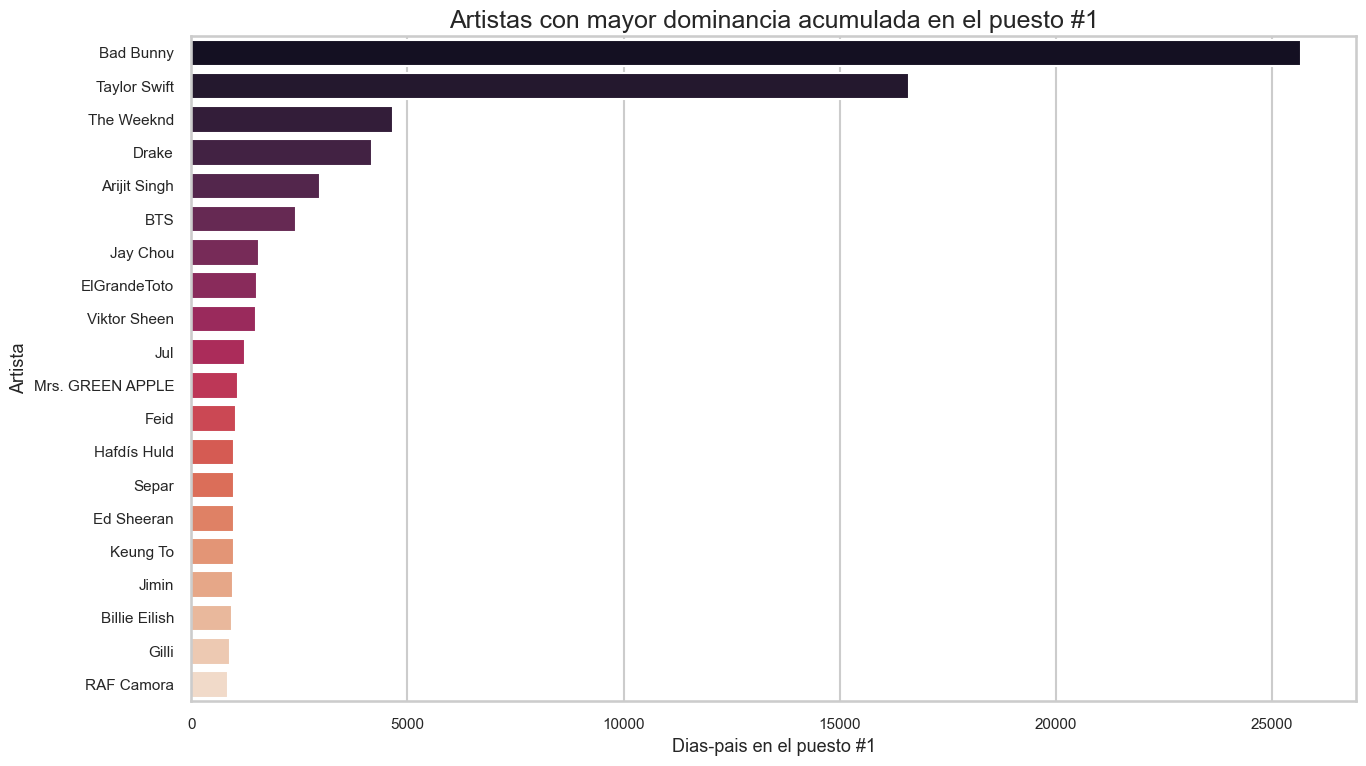

In [35]:
if not top_no1.empty:
    total_no1 = top_no1['dias_pais_en_no1'].sum()
    share_top10 = top_no1.head(10)['dias_pais_en_no1'].sum() / total_no1
    lider = top_no1.iloc[0]
    print(f"Los 10 artistas con mas dias-pais en el puesto #1 concentran el {share_top10:.1%} de todos los liderazgos del dataset.")
    print(f"El artista mas dominante es {lider['artist_name']} con {int(lider['dias_pais_en_no1']):,} dias-pais en #1 y presencia de liderazgo en {int(lider['paises_con_no1'])} paises.")

    plt.figure(figsize=(14, 8))
    sns.barplot(data=top_no1.head(20), x='dias_pais_en_no1', y='artist_name', palette='rocket')
    plt.title('Artistas con mayor dominancia acumulada en el puesto #1')
    plt.xlabel('Dias-pais en el puesto #1')
    plt.ylabel('Artista')
    plt.tight_layout()
    plt.savefig(DIR_OUTPUTS / '10_artistas_dominancia_no1.png', dpi=160, bbox_inches='tight')
    plt.show()


## 6. Insight 2: alcance global vs dominancia local

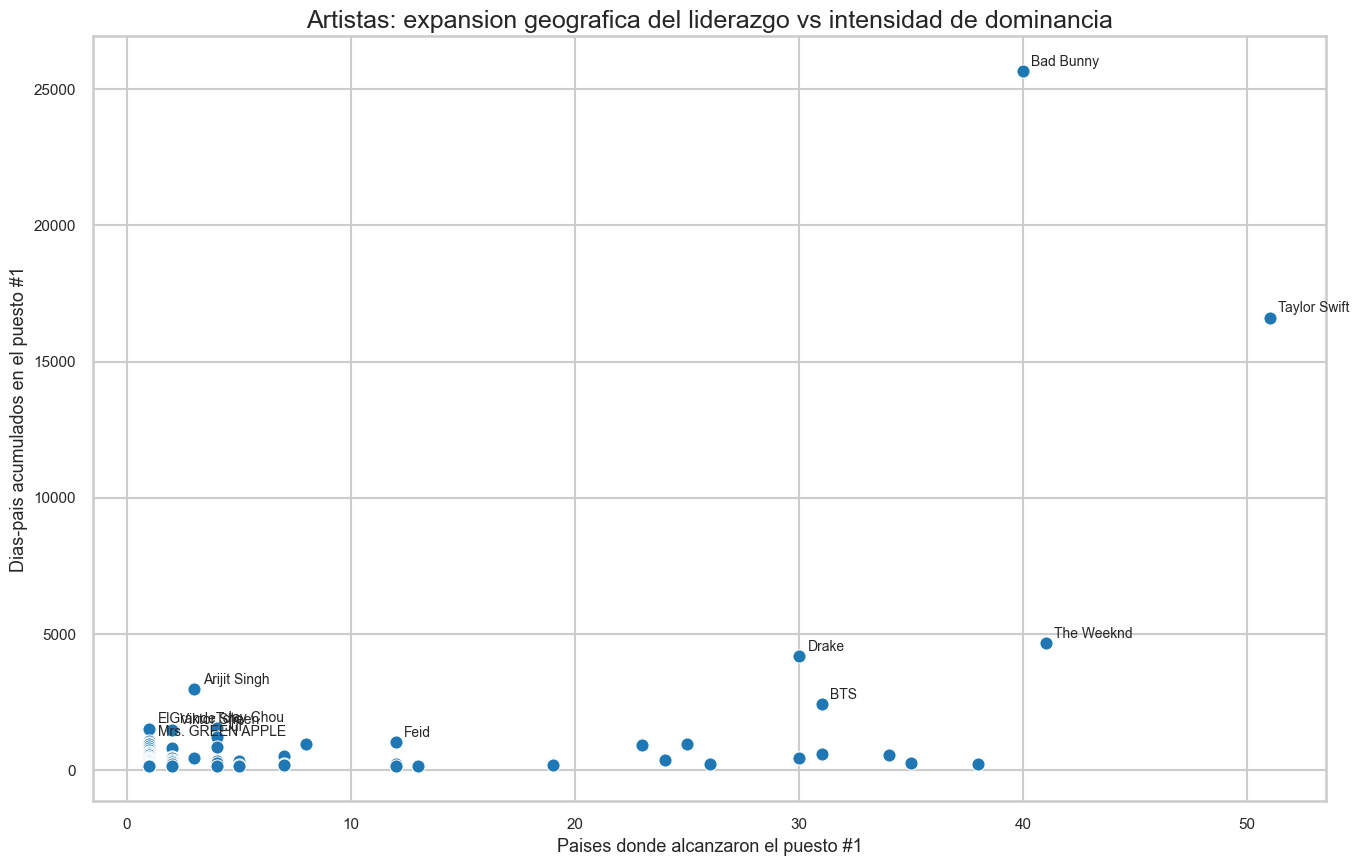

Lideres mas claramente locales:


,artist_name,dias_pais_en_no1,paises_con_no1
4,Arijit Singh,2972,3
7,ElGrandeToto,1519,1
8,Viktor Sheen,1498,2
10,Mrs. GREEN APPLE,1067,1
12,Hafdís Huld,988,1


Lideres mas claramente globales:


,artist_name,dias_pais_en_no1,paises_con_no1
0,Bad Bunny,25666,40
1,Taylor Swift,16612,51
2,The Weeknd,4662,41
3,Drake,4181,30
5,BTS,2431,31


In [36]:
if not top_no1.empty:
    pdf_alcance = top_no1[top_no1['dias_pais_en_no1'] >= 150].copy()
    destacar = pdf_alcance.sort_values(['dias_pais_en_no1', 'paises_con_no1'], ascending=[False, False]).head(12)

    plt.figure(figsize=(14, 9))
    sns.scatterplot(
        data=pdf_alcance,
        x='paises_con_no1',
        y='dias_pais_en_no1',
        s=90,
        color='#1f78b4'
    )
    for _, fila in destacar.iterrows():
        plt.annotate(fila['artist_name'], (fila['paises_con_no1'], fila['dias_pais_en_no1']), xytext=(6, 4), textcoords='offset points', fontsize=10)

    plt.title('Artistas: expansion geografica del liderazgo vs intensidad de dominancia')
    plt.xlabel('Paises donde alcanzaron el puesto #1')
    plt.ylabel('Dias-pais acumulados en el puesto #1')
    plt.tight_layout()
    plt.savefig(DIR_OUTPUTS / '11_alcance_global_vs_dominancia_local.png', dpi=160, bbox_inches='tight')
    plt.show()

    locales = pdf_alcance[pdf_alcance['paises_con_no1'] <= 3].sort_values('dias_pais_en_no1', ascending=False).head(5)
    globales = pdf_alcance[pdf_alcance['paises_con_no1'] >= 20].sort_values('dias_pais_en_no1', ascending=False).head(5)
    print('Lideres mas claramente locales:')
    display(locales)
    print('Lideres mas claramente globales:')
    display(globales)


## 7. Insight 3: estabilidad y recambio del Top 10 de artistas

In [37]:
artistas_top10_diario = (
    chart_artistas.where(F.col('rank') <= 10)
    .groupBy('fecha')
    .agg(
        F.avg(F.when(F.col('entry_status') == 'NEW_ENTRY', 1).otherwise(0)).alias('share_new_entry'),
        F.avg(F.when(F.col('entry_status') == 'RE_ENTRY', 1).otherwise(0)).alias('share_re_entry'),
        F.avg(F.when(F.col('entry_status') == 'NO_CHANGE', 1).otherwise(0)).alias('share_no_change'),
        F.avg(F.when(F.col('entry_status').isin('MOVED_UP', 'MOVED_DOWN'), 1).otherwise(0)).alias('share_movement')
    )
    .orderBy('fecha')
    .toPandas()
)

artistas_top10_diario.head()


,fecha,share_new_entry,share_re_entry,share_no_change,share_movement
0,2021-10-21,1.000000,0.0,0.000000,0.000000
1,2021-10-22,0.004478,0.0,0.465672,0.529851
2,2021-10-23,0.000000,0.0,0.561194,0.438806
3,2021-10-24,0.000000,0.0,0.637313,0.362687
4,2021-10-25,0.000000,0.0,0.579104,0.420896


En promedio, solo el 1.50% del Top 10 diario corresponde a ingresos nuevos o reingresos.
En promedio, el 60.68% del Top 10 permanece sin cambios entre un dia y otro.
El mayor pico de recambio ocurre el 2021-10-21 con un 100.00% de entradas o reentradas.


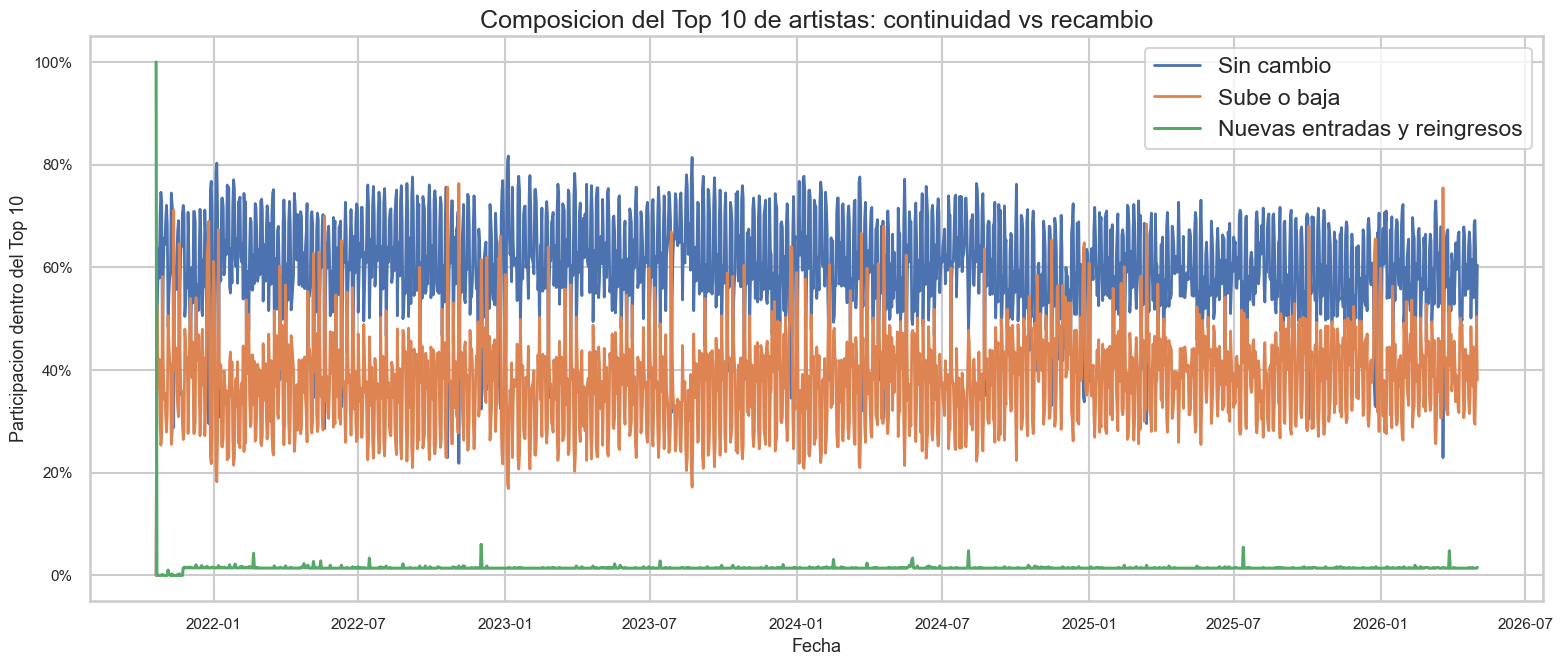

In [38]:
if not artistas_top10_diario.empty:
    artistas_top10_diario['share_ingresos'] = artistas_top10_diario['share_new_entry'] + artistas_top10_diario['share_re_entry']
    promedio_ingresos = artistas_top10_diario['share_ingresos'].mean()
    promedio_no_change = artistas_top10_diario['share_no_change'].mean()
    pico = artistas_top10_diario.loc[artistas_top10_diario['share_ingresos'].idxmax()]

    print(f"En promedio, solo el {promedio_ingresos:.2%} del Top 10 diario corresponde a ingresos nuevos o reingresos.")
    print(f"En promedio, el {promedio_no_change:.2%} del Top 10 permanece sin cambios entre un dia y otro.")
    print(f"El mayor pico de recambio ocurre el {pico['fecha']} con un {pico['share_ingresos']:.2%} de entradas o reentradas.")

    plt.figure(figsize=(16, 7))
    plt.plot(artistas_top10_diario['fecha'], artistas_top10_diario['share_no_change'], label='Sin cambio', linewidth=2.0)
    plt.plot(artistas_top10_diario['fecha'], artistas_top10_diario['share_movement'], label='Sube o baja', linewidth=2.0)
    plt.plot(artistas_top10_diario['fecha'], artistas_top10_diario['share_ingresos'], label='Nuevas entradas y reingresos', linewidth=2.2)
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.title('Composicion del Top 10 de artistas: continuidad vs recambio')
    plt.xlabel('Fecha')
    plt.ylabel('Participacion dentro del Top 10')
    plt.legend()
    plt.tight_layout()
    plt.savefig(DIR_OUTPUTS / '12_estabilidad_top10_artistas.png', dpi=160, bbox_inches='tight')
    plt.show()


## 8. Insight 4: permanencia en chart segun banda de posicion

In [39]:
permanencia_por_banda = (
    chart_artistas.where(F.col('rank').isNotNull() & F.col('days_on_chart').isNotNull())
    .withColumn('banda_rank', banda_rank('rank'))
    .groupBy('banda_rank')
    .agg(
        F.percentile_approx('days_on_chart', 0.5, 1000).alias('mediana_dias_en_chart'),
        F.percentile_approx('consecutive_days', 0.5, 1000).alias('mediana_dias_consecutivos'),
        F.avg(F.when(F.col('entry_status') == 'NEW_ENTRY', 1).otherwise(0)).alias('share_new_entry')
    )
    .toPandas()
)

if not permanencia_por_banda.empty:
    permanencia_por_banda['orden'] = permanencia_por_banda['banda_rank'].map({b: i for i, b in enumerate(ORDEN_BANDAS)})
    permanencia_por_banda = permanencia_por_banda.sort_values('orden')
    permanencia_por_banda


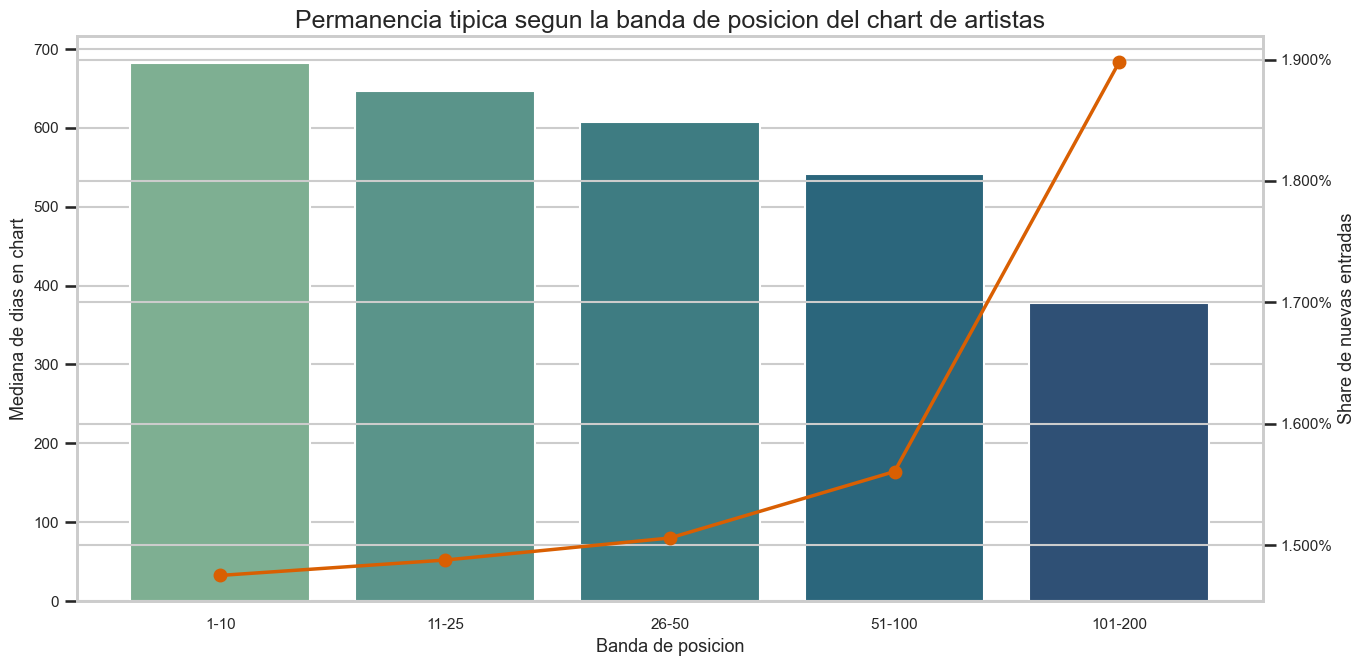

La mediana de permanencia en la banda 1-10 es de 682 dias, frente a 378 dias en la banda 101-200.


In [40]:
if not permanencia_por_banda.empty:
    fig, ax1 = plt.subplots(figsize=(14, 7))
    sns.barplot(data=permanencia_por_banda, x='banda_rank', y='mediana_dias_en_chart', palette='crest', ax=ax1)
    ax1.set_title('Permanencia tipica segun la banda de posicion del chart de artistas')
    ax1.set_xlabel('Banda de posicion')
    ax1.set_ylabel('Mediana de dias en chart')

    ax2 = ax1.twinx()
    ax2.plot(permanencia_por_banda['banda_rank'], permanencia_por_banda['share_new_entry'], color='#d95f02', marker='o', linewidth=2.5)
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.set_ylabel('Share de nuevas entradas')

    plt.tight_layout()
    plt.savefig(DIR_OUTPUTS / '13_permanencia_por_banda_rank.png', dpi=160, bbox_inches='tight')
    plt.show()

    top10 = permanencia_por_banda.loc[permanencia_por_banda['banda_rank'] == '1-10', 'mediana_dias_en_chart'].iloc[0]
    bottom = permanencia_por_banda.loc[permanencia_por_banda['banda_rank'] == '101-200', 'mediana_dias_en_chart'].iloc[0]
    print(f"La mediana de permanencia en la banda 1-10 es de {int(top10)} dias, frente a {int(bottom)} dias en la banda 101-200.")


## 9. Insight 5: diversidad de lideres diarios en el puesto #1

In [41]:
diversidad_no1 = (
    chart_artistas.where(F.col('rank') == 1)
    .groupBy('fecha')
    .agg(F.countDistinct('artist_name').alias('artistas_distintos_en_no1'))
    .orderBy('fecha')
    .toPandas()
)

if not diversidad_no1.empty:
    diversidad_no1['promedio_30d'] = diversidad_no1['artistas_distintos_en_no1'].rolling(30, min_periods=1).mean()
    diversidad_no1.head()


En un dia tipico, el puesto #1 es ocupado por 36.3 artistas distintos al sumar todos los paises.
El minimo observado fue 15 y el maximo 50 artistas distintos liderando simultaneamente.


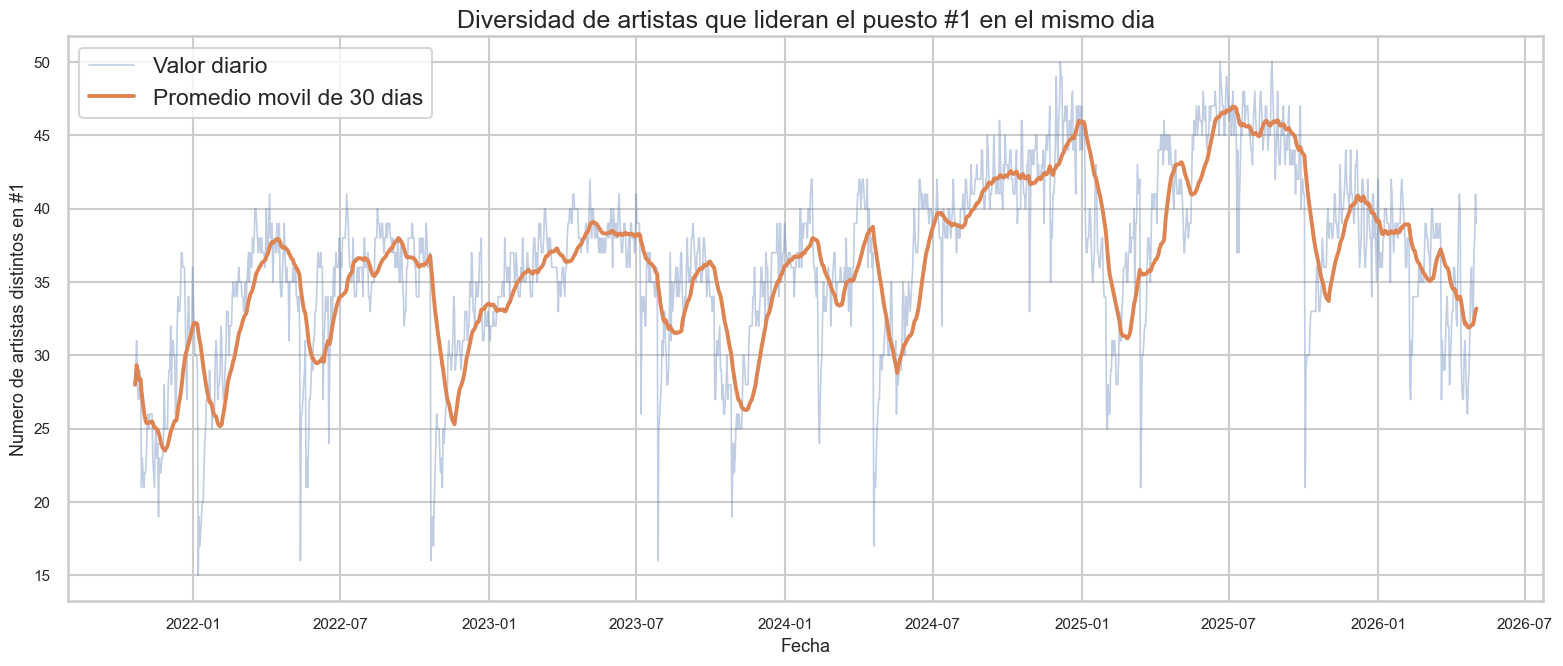

In [42]:
if not diversidad_no1.empty:
    minimo = diversidad_no1['artistas_distintos_en_no1'].min()
    maximo = diversidad_no1['artistas_distintos_en_no1'].max()
    promedio = diversidad_no1['artistas_distintos_en_no1'].mean()
    print(f"En un dia tipico, el puesto #1 es ocupado por {promedio:.1f} artistas distintos al sumar todos los paises.")
    print(f"El minimo observado fue {int(minimo)} y el maximo {int(maximo)} artistas distintos liderando simultaneamente.")

    plt.figure(figsize=(16, 7))
    plt.plot(diversidad_no1['fecha'], diversidad_no1['artistas_distintos_en_no1'], alpha=0.35, linewidth=1.2, label='Valor diario')
    plt.plot(diversidad_no1['fecha'], diversidad_no1['promedio_30d'], linewidth=2.8, label='Promedio movil de 30 dias')
    plt.title('Diversidad de artistas que lideran el puesto #1 en el mismo dia')
    plt.xlabel('Fecha')
    plt.ylabel('Numero de artistas distintos en #1')
    plt.legend()
    plt.tight_layout()
    plt.savefig(DIR_OUTPUTS / '14_diversidad_lideres_no1.png', dpi=160, bbox_inches='tight')
    plt.show()


## 10. Insight 6: mercados mas estables y mas volatiles en el Top 10 de artistas

In [43]:
diagnostico_mercados = (
    chart_artistas.where(F.col('rank') <= 10)
    .groupBy('pais')
    .agg(
        F.count('*').alias('observaciones_top10'),
        F.countDistinct('fecha').alias('dias_cubiertos'),
        F.avg(F.when(F.col('entry_status') == 'NEW_ENTRY', 1).otherwise(0)).alias('share_new_entry_top10'),
        F.avg(F.when(F.col('entry_status') == 'NO_CHANGE', 1).otherwise(0)).alias('share_no_change_top10'),
        F.percentile_approx('days_on_chart', 0.5, 1000).alias('mediana_days_on_chart')
    )
    .where(F.col('observaciones_top10') >= 1000)
)

mercados_anomalos = (
    diagnostico_mercados
    .where(
        (F.col('share_new_entry_top10') >= 0.90) |
        ((F.col('share_no_change_top10') == 0) & (F.col('mediana_days_on_chart') <= 1))
    )
    .orderBy('pais')
    .toPandas()
)

volatilidad_por_pais = (
    diagnostico_mercados
    .where(
        (F.col('share_new_entry_top10') < 0.90) &
        ~((F.col('share_no_change_top10') == 0) & (F.col('mediana_days_on_chart') <= 1))
    )
    .orderBy(F.desc('share_new_entry_top10'))
    .toPandas()
)

if not mercados_anomalos.empty:
    print('Mercados excluidos por patron anomalo del dataset:')
    display(mercados_anomalos)

volatilidad_por_pais.head(15)


Mercados excluidos por patron anomalo del dataset:


,pais,observaciones_top10,dias_cubiertos,share_new_entry_top10,share_no_change_top10,mediana_days_on_chart
0,ve,16210,1621,1.0,0.0,1


,pais,observaciones_top10,dias_cubiertos,share_new_entry_top10,share_no_change_top10,mediana_days_on_chart
0,lu,16550,1655,0.004773,0.421994,613
1,th,16550,1655,0.001692,0.565196,626
2,is,16550,1655,0.001631,0.503142,691
3,vn,16550,1655,0.001511,0.576375,574
4,ee,16550,1655,0.001450,0.515468,687
5,sa,16550,1655,0.001208,0.607311,726
6,cz,16550,1655,0.001088,0.624230,799
7,kr,16550,1655,0.001088,0.634985,558
8,at,16550,1655,0.001027,0.536375,730
9,ae,16550,1655,0.001027,0.652810,746


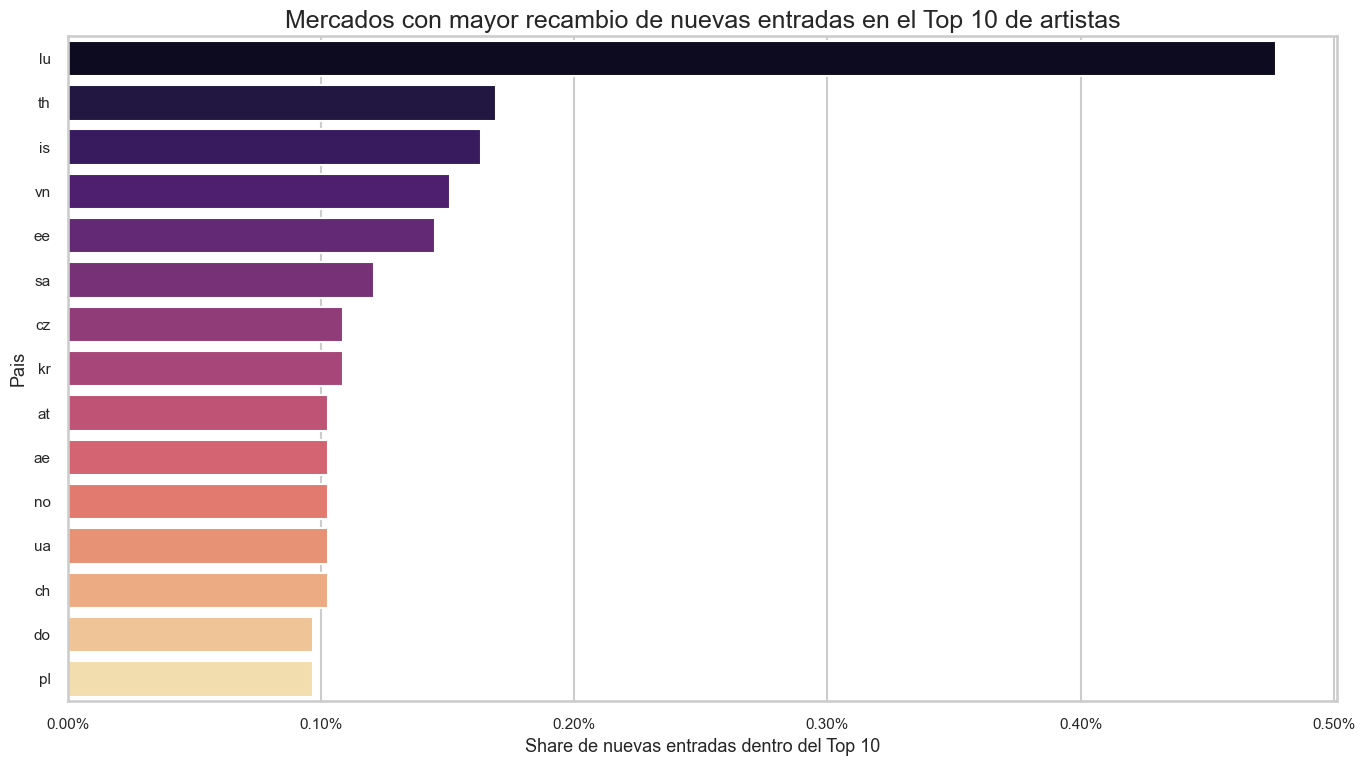

Nota metodologica: se excluyeron mercados con patron claramente anomalo, por ejemplo aquellos donde casi el 100% del Top 10 aparece como NEW_ENTRY todos los dias.
Mercados mas estables segun el share de posiciones sin cambio en el Top 10:


,pais,share_no_change_top10,share_new_entry_top10,observaciones_top10,dias_cubiertos,mediana_days_on_chart
65,in,0.853172,0.000604,16550,1655,797
60,eg,0.757281,0.000665,16550,1655,708
66,jp,0.737160,0.000604,16550,1655,738
45,pk,0.735059,0.000759,14490,1449,700
43,sv,0.732024,0.000785,16550,1655,683
56,co,0.722356,0.000725,16550,1655,752
64,cl,0.717039,0.000604,16550,1655,635
67,es,0.715166,0.000604,16550,1655,705
37,ph,0.712266,0.000785,16550,1655,627
59,pe,0.707976,0.000665,16550,1655,776


Mercados mas volatiles despues de limpiar anomalias:


,pais,share_new_entry_top10,share_no_change_top10,observaciones_top10,dias_cubiertos,mediana_days_on_chart
0,lu,0.004773,0.421994,16550,1655,613
1,th,0.001692,0.565196,16550,1655,626
2,is,0.001631,0.503142,16550,1655,691
3,vn,0.001511,0.576375,16550,1655,574
4,ee,0.001450,0.515468,16550,1655,687
5,sa,0.001208,0.607311,16550,1655,726
6,cz,0.001088,0.624230,16550,1655,799
7,kr,0.001088,0.634985,16550,1655,558
8,at,0.001027,0.536375,16550,1655,730
9,ae,0.001027,0.652810,16550,1655,746


In [44]:
if not volatilidad_por_pais.empty:
    top_volatiles = volatilidad_por_pais.head(15).copy()
    plt.figure(figsize=(14, 8))
    sns.barplot(data=top_volatiles, x='share_new_entry_top10', y='pais', palette='magma')
    plt.gca().xaxis.set_major_formatter(PercentFormatter(1.0))
    plt.title('Mercados con mayor recambio de nuevas entradas en el Top 10 de artistas')
    plt.xlabel('Share de nuevas entradas dentro del Top 10')
    plt.ylabel('Pais')
    plt.tight_layout()
    plt.savefig(DIR_OUTPUTS / '15_mercados_mas_volatiles_top10_artistas.png', dpi=160, bbox_inches='tight')
    plt.show()

    print('Nota metodologica: se excluyeron mercados con patron claramente anomalo, por ejemplo aquellos donde casi el 100% del Top 10 aparece como NEW_ENTRY todos los dias.')

    top_estables = volatilidad_por_pais.sort_values('share_no_change_top10', ascending=False).head(10)
    print('Mercados mas estables segun el share de posiciones sin cambio en el Top 10:')
    display(top_estables[['pais', 'share_no_change_top10', 'share_new_entry_top10', 'observaciones_top10', 'dias_cubiertos', 'mediana_days_on_chart']])

    print('Mercados mas volatiles despues de limpiar anomalias:')
    display(top_volatiles[['pais', 'share_new_entry_top10', 'share_no_change_top10', 'observaciones_top10', 'dias_cubiertos', 'mediana_days_on_chart']])


## 11. Insight 7: poder de los sellos en el chart de albumes

In [45]:
labels_top10 = (
    chart_albumes.where(F.col('rank') <= 10)
    .withColumn('label_limpio', F.when(F.trim(F.col('label')) == '', F.lit('Sin etiqueta')).otherwise(F.coalesce(F.col('label'), F.lit('Sin etiqueta'))))
    .groupBy('label_limpio')
    .agg(
        F.count('*').alias('semanas_en_top10'),
        F.countDistinct('album_uri').alias('albumes_distintos')
    )
    .orderBy(F.desc('semanas_en_top10'))
    .toPandas()
)

labels_no1 = (
    chart_albumes.where(F.col('rank') == 1)
    .withColumn('label_limpio', F.when(F.trim(F.col('label')) == '', F.lit('Sin etiqueta')).otherwise(F.coalesce(F.col('label'), F.lit('Sin etiqueta'))))
    .groupBy('label_limpio')
    .agg(F.count('*').alias('semanas_en_no1'))
    .orderBy(F.desc('semanas_en_no1'))
    .toPandas()
)

labels_top10.head(12)


,label_limpio,semanas_en_top10,albumes_distintos
0,Rimas Entertainment LLC,7581,21
1,Columbia,5700,92
2,Taylor Swift,5001,20
3,Warner Records,3493,27
4,BIGHIT MUSIC,3434,32
5,Republic Records,3067,25
6,Atlantic Records,2972,39
7,Olivia Rodrigo PS,2172,2
8,UMLE - Latino,2091,8
9,Darkroom/Interscope Records,1932,3


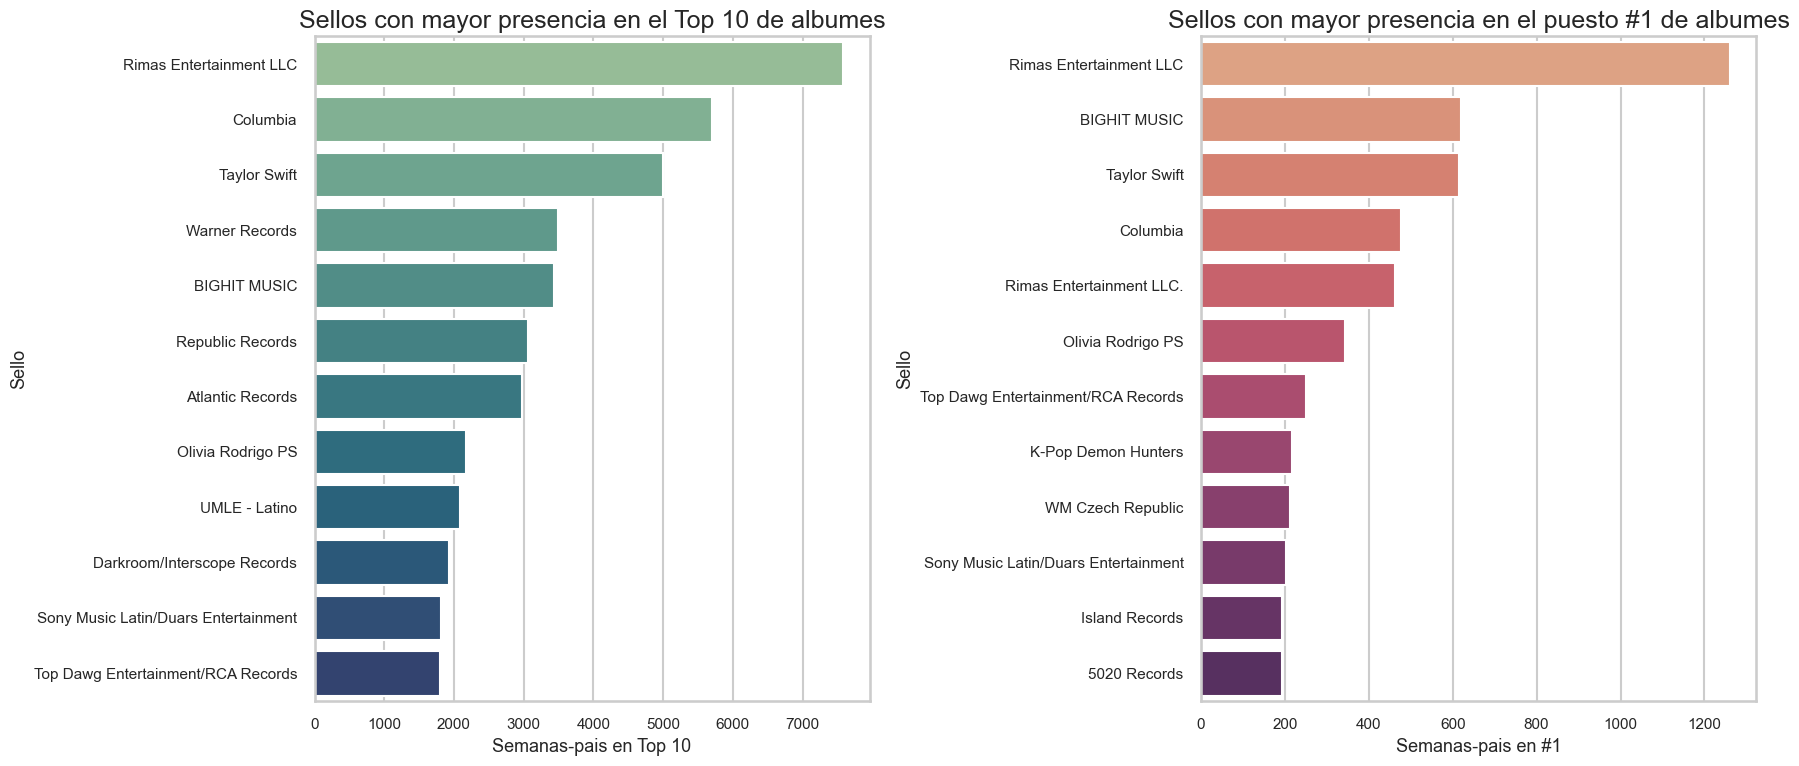

El sello con mayor presencia en el Top 10 de albumes es Rimas Entertainment LLC con 7,581 semanas-pais en esa zona alta del chart.


In [46]:
if not labels_top10.empty:
    fig, axes = plt.subplots(1, 2, figsize=(18, 8))
    sns.barplot(data=labels_top10.head(12), x='semanas_en_top10', y='label_limpio', palette='crest', ax=axes[0])
    axes[0].set_title('Sellos con mayor presencia en el Top 10 de albumes')
    axes[0].set_xlabel('Semanas-pais en Top 10')
    axes[0].set_ylabel('Sello')

    sns.barplot(data=labels_no1.head(12), x='semanas_en_no1', y='label_limpio', palette='flare', ax=axes[1])
    axes[1].set_title('Sellos con mayor presencia en el puesto #1 de albumes')
    axes[1].set_xlabel('Semanas-pais en #1')
    axes[1].set_ylabel('Sello')

    plt.tight_layout()
    plt.savefig(DIR_OUTPUTS / '16_poder_de_los_sellos_albumes.png', dpi=160, bbox_inches='tight')
    plt.show()

lider_sello = labels_top10.iloc[0]
    
print(f"El sello con mayor presencia en el Top 10 de albumes es {lider_sello['label_limpio']} con {int(lider_sello['semanas_en_top10']):,} semanas-pais en esa zona alta del chart.")


## 12. Insight 8: velocidad de entrada al chart tras el lanzamiento

In [47]:
lag_albumes = (
    chart_albumes.where(
        F.col('days_release_to_entry').isNotNull() &
        (F.col('days_release_to_entry') >= 0) &
        (F.col('days_release_to_entry') <= 3650)
    )
    .withColumn(
        'bucket_lag',
        F.when(F.col('days_release_to_entry') <= 7, '0-7')
        .when(F.col('days_release_to_entry') <= 30, '8-30')
        .when(F.col('days_release_to_entry') <= 180, '31-180')
        .when(F.col('days_release_to_entry') <= 365, '181-365')
        .otherwise('366-3650')
    )
    .groupBy('bucket_lag')
    .count()
    .toPandas()
)

if not lag_albumes.empty:
    lag_albumes['orden'] = lag_albumes['bucket_lag'].map({b: i for i, b in enumerate(ORDEN_LAG)})
    lag_albumes = lag_albumes.sort_values('orden')
    lag_albumes['share'] = lag_albumes['count'] / lag_albumes['count'].sum()
    lag_albumes


El 38.0% de las entradas validas ocurre dentro de la primera semana posterior al lanzamiento.
El 41.3% entra en el primer mes.
Aun asi, el 45.7% corresponde a entradas tardias de mas de un ano, lo que sugiere un catalogo viejo que sigue reactivandose.


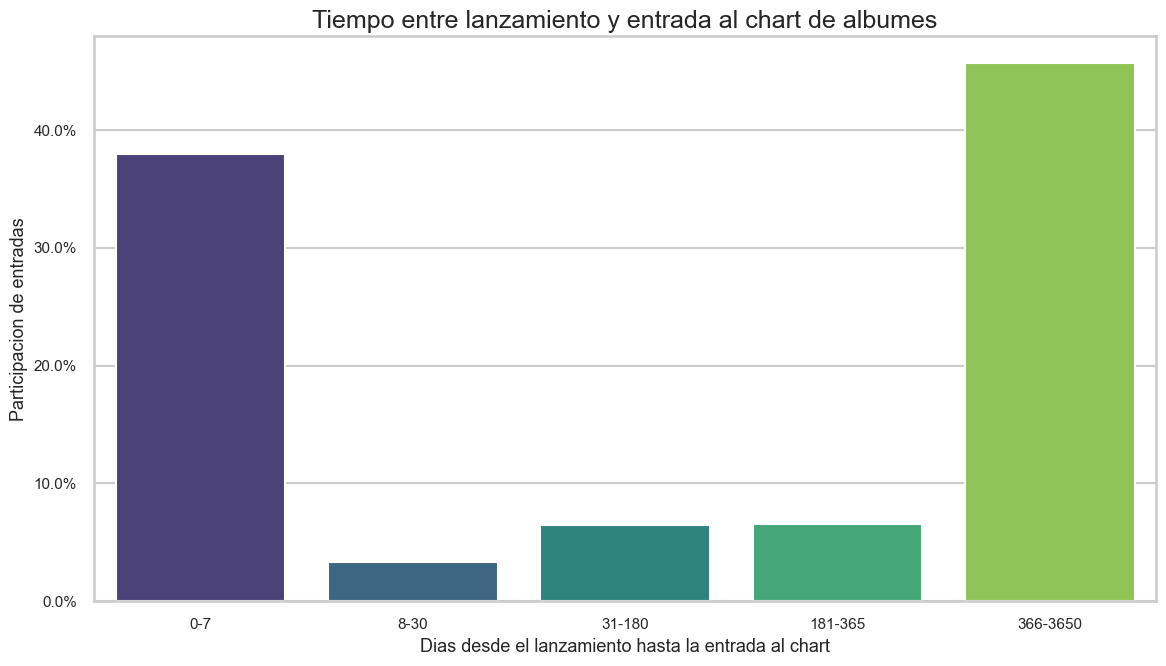

In [48]:
if not lag_albumes.empty:
    share_7 = lag_albumes.loc[lag_albumes['bucket_lag'] == '0-7', 'share'].iloc[0]
    share_30 = lag_albumes.loc[lag_albumes['bucket_lag'].isin(['0-7', '8-30']), 'share'].sum()
    share_catalogo = lag_albumes.loc[lag_albumes['bucket_lag'] == '366-3650', 'share'].iloc[0]
    print(f"El {share_7:.1%} de las entradas validas ocurre dentro de la primera semana posterior al lanzamiento.")
    print(f"El {share_30:.1%} entra en el primer mes.")
    print(f"Aun asi, el {share_catalogo:.1%} corresponde a entradas tardias de mas de un ano, lo que sugiere un catalogo viejo que sigue reactivandose.")

    plt.figure(figsize=(12, 7))
    sns.barplot(data=lag_albumes, x='bucket_lag', y='share', palette='viridis')
    plt.gca().yaxis.set_major_formatter(PercentFormatter(1.0))
    plt.title('Tiempo entre lanzamiento y entrada al chart de albumes')
    plt.xlabel('Dias desde el lanzamiento hasta la entrada al chart')
    plt.ylabel('Participacion de entradas')
    plt.tight_layout()
    plt.savefig(DIR_OUTPUTS / '17_velocidad_entrada_albumes.png', dpi=160, bbox_inches='tight')
    plt.show()


## 13. Insight 9: fuerza del debut vs permanencia de albumes

In [49]:
debut_vs_permanencia = (
    chart_albumes.where(F.col('entry_rank').isNotNull() & F.col('weeks_on_chart').isNotNull())
    .withColumn('banda_entry', banda_rank('entry_rank'))
    .groupBy('banda_entry')
    .agg(
        F.percentile_approx('weeks_on_chart', 0.5, 1000).alias('mediana_semanas_en_chart'),
        F.avg(F.when(F.col('rank') <= 10, 1).otherwise(0)).alias('share_tiempo_en_top10')
    )
    .toPandas()
)

if not debut_vs_permanencia.empty:
    debut_vs_permanencia['orden'] = debut_vs_permanencia['banda_entry'].map({b: i for i, b in enumerate(ORDEN_BANDAS)})
    debut_vs_permanencia = debut_vs_permanencia.sort_values('orden')
    debut_vs_permanencia


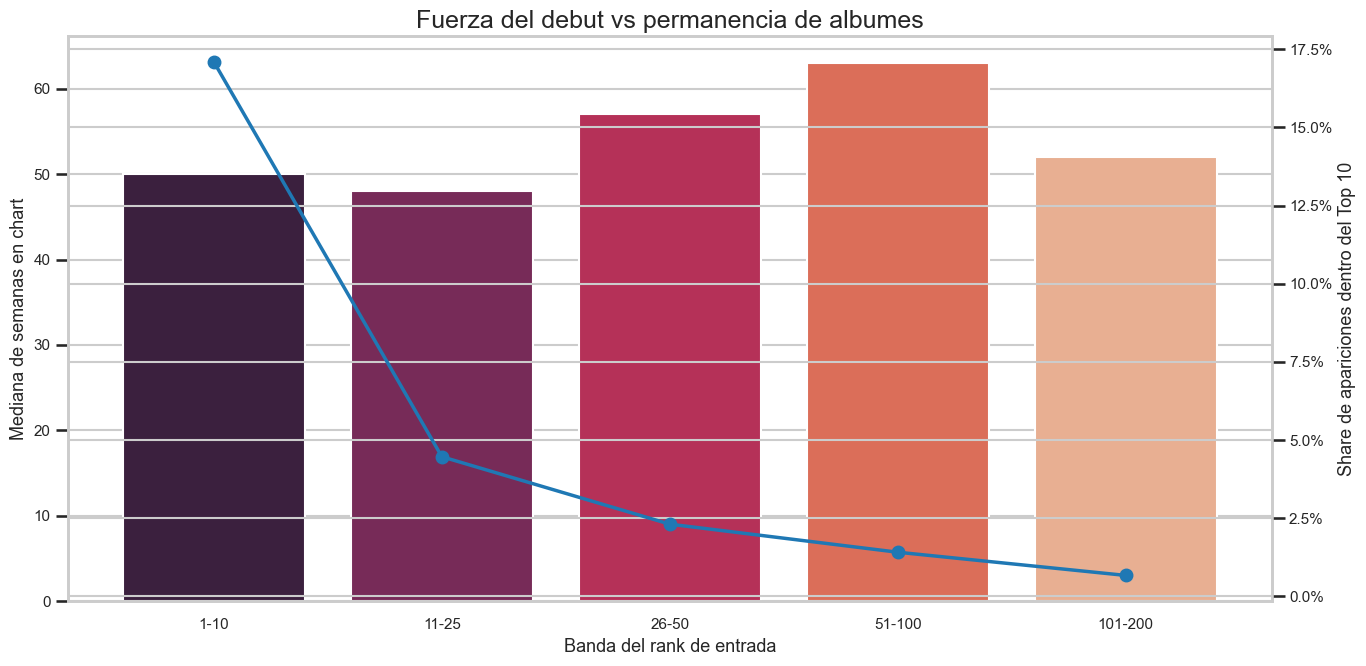

,banda_entry,mediana_semanas_en_chart,share_tiempo_en_top10
4,1-10,50,0.170923
0,11-25,48,0.044668
2,26-50,57,0.023100
3,51-100,63,0.014125
1,101-200,52,0.006708


In [50]:
if not debut_vs_permanencia.empty:
    fig, ax1 = plt.subplots(figsize=(14, 7))
    sns.barplot(data=debut_vs_permanencia, x='banda_entry', y='mediana_semanas_en_chart', palette='rocket', ax=ax1)
    ax1.set_title('Fuerza del debut vs permanencia de albumes')
    ax1.set_xlabel('Banda del rank de entrada')
    ax1.set_ylabel('Mediana de semanas en chart')

    ax2 = ax1.twinx()
    ax2.plot(debut_vs_permanencia['banda_entry'], debut_vs_permanencia['share_tiempo_en_top10'], color='#1f78b4', marker='o', linewidth=2.5)
    ax2.yaxis.set_major_formatter(PercentFormatter(1.0))
    ax2.set_ylabel('Share de apariciones dentro del Top 10')

    plt.tight_layout()
    plt.savefig(DIR_OUTPUTS / '18_debut_vs_permanencia_albumes.png', dpi=160, bbox_inches='tight')
    plt.show()

    display(debut_vs_permanencia[['banda_entry', 'mediana_semanas_en_chart', 'share_tiempo_en_top10']])


## 14. Resumen ejecutivo automatico

Esta seccion convierte los resultados numericos del notebook en conclusiones redactadas en espanol.

In [51]:
if not top_no1.empty:
    total_no1 = top_no1['dias_pais_en_no1'].sum()
    share_top10_no1 = top_no1.head(10)['dias_pais_en_no1'].sum() / total_no1
    artista_lider = top_no1.iloc[0]
else:
    share_top10_no1 = None
    artista_lider = None

if not artistas_top10_diario.empty:
    artistas_top10_diario['share_ingresos'] = artistas_top10_diario['share_new_entry'] + artistas_top10_diario['share_re_entry']
    promedio_ingresos = artistas_top10_diario['share_ingresos'].mean()
    promedio_no_change = artistas_top10_diario['share_no_change'].mean()
else:
    promedio_ingresos = None
    promedio_no_change = None

if not diversidad_no1.empty:
    promedio_diversidad = diversidad_no1['artistas_distintos_en_no1'].mean()
    minimo_diversidad = diversidad_no1['artistas_distintos_en_no1'].min()
    maximo_diversidad = diversidad_no1['artistas_distintos_en_no1'].max()
else:
    promedio_diversidad = None
    minimo_diversidad = None
    maximo_diversidad = None

if not permanencia_por_banda.empty:
    mediana_top10 = permanencia_por_banda.loc[permanencia_por_banda['banda_rank'] == '1-10', 'mediana_dias_en_chart'].iloc[0]
    mediana_bottom = permanencia_por_banda.loc[permanencia_por_banda['banda_rank'] == '101-200', 'mediana_dias_en_chart'].iloc[0]
else:
    mediana_top10 = None
    mediana_bottom = None

if not labels_top10.empty:
    sello_lider = labels_top10.iloc[0]
else:
    sello_lider = None

if not lag_albumes.empty:
    share_7 = lag_albumes.loc[lag_albumes['bucket_lag'] == '0-7', 'share'].iloc[0]
    share_30 = lag_albumes.loc[lag_albumes['bucket_lag'].isin(['0-7', '8-30']), 'share'].sum()
    share_catalogo = lag_albumes.loc[lag_albumes['bucket_lag'] == '366-3650', 'share'].iloc[0]
else:
    share_7 = None
    share_30 = None
    share_catalogo = None

if not debut_vs_permanencia.empty:
    mejor_debut = debut_vs_permanencia.sort_values('share_tiempo_en_top10', ascending=False).iloc[0]
    mayor_longevidad = debut_vs_permanencia.sort_values('mediana_semanas_en_chart', ascending=False).iloc[0]
else:
    mejor_debut = None
    mayor_longevidad = None

resumen_ejecutivo = []

if artista_lider is not None:
    resumen_ejecutivo.append(
        f"1. Concentracion del liderazgo: los 10 artistas con mas dias-pais en el puesto #1 concentran el {share_top10_no1:.1%} de todos los liderazgos observados. El lider principal es {artista_lider['artist_name']}, con {int(artista_lider['dias_pais_en_no1']):,} dias-pais en #1 distribuidos en {int(artista_lider['paises_con_no1'])} paises."
    )

if promedio_ingresos is not None:
    resumen_ejecutivo.append(
        f"2. Estabilidad del Top 10: en promedio, solo el {promedio_ingresos:.2%} del Top 10 diario de artistas corresponde a entradas nuevas o reingresos, mientras que el {promedio_no_change:.2%} permanece sin cambios de un dia a otro. Esto sugiere una zona alta del chart bastante estable."
    )

if promedio_diversidad is not None:
    resumen_ejecutivo.append(
        f"3. Diversidad del puesto #1 entre paises: en un dia promedio, el puesto #1 es ocupado por {promedio_diversidad:.1f} artistas distintos al sumar todos los mercados. El minimo observado fue {int(minimo_diversidad)} y el maximo {int(maximo_diversidad)}, lo que indica que existe diversidad geografica, aunque no necesariamente baja concentracion global."
    )

if mediana_top10 is not None:
    resumen_ejecutivo.append(
        f"4. Permanencia y posicion: la mediana de permanencia en chart para artistas ubicados entre el puesto 1 y 10 es de {int(mediana_top10)} dias, frente a {int(mediana_bottom)} dias para quienes estan entre el 101 y el 200. Las posiciones altas no parecen estar dominadas por trayectorias efimeras."
    )

if sello_lider is not None:
    resumen_ejecutivo.append(
        f"5. Poder de los sellos: {sello_lider['label_limpio']} es el sello con mayor presencia en el Top 10 de albumes, con {int(sello_lider['semanas_en_top10']):,} semanas-pais en esa franja alta. Esto apunta a una capacidad sostenida de colocar catalogo en las zonas premium del chart."
    )

if share_7 is not None:
    resumen_ejecutivo.append(
        f"6. Ventana de entrada al chart: el {share_7:.1%} de las entradas validas de albumes ocurre dentro de la primera semana tras el lanzamiento y el {share_30:.1%} entra en el primer mes. Aun asi, el {share_catalogo:.1%} corresponde a entradas muy tardias de mas de un ano, lo que muestra la fuerza recurrente del catalogo viejo."
    )

if mejor_debut is not None:
    resumen_ejecutivo.append(
        f"7. Debut vs longevidad: la banda de entrada con mayor permanencia mediana es {mayor_longevidad['banda_entry']} con {int(mayor_longevidad['mediana_semanas_en_chart'])} semanas, mientras que la banda con mayor participacion posterior en Top 10 es {mejor_debut['banda_entry']} con {mejor_debut['share_tiempo_en_top10']:.2%}. Esto sugiere que debutar fuerte ayuda, pero no garantiza automaticamente la mayor longevidad."
    )

for parrafo in resumen_ejecutivo:
    print(parrafo)


1. Concentracion del liderazgo: los 10 artistas con mas dias-pais en el puesto #1 concentran el 53.3% de todos los liderazgos observados. El lider principal es Bad Bunny, con 25,666 dias-pais en #1 distribuidos en 40 paises.
2. Estabilidad del Top 10: en promedio, solo el 1.50% del Top 10 diario de artistas corresponde a entradas nuevas o reingresos, mientras que el 60.68% permanece sin cambios de un dia a otro. Esto sugiere una zona alta del chart bastante estable.
3. Diversidad del puesto #1 entre paises: en un dia promedio, el puesto #1 es ocupado por 36.3 artistas distintos al sumar todos los mercados. El minimo observado fue 15 y el maximo 50, lo que indica que existe diversidad geografica, aunque no necesariamente baja concentracion global.
4. Permanencia y posicion: la mediana de permanencia en chart para artistas ubicados entre el puesto 1 y 10 es de 682 dias, frente a 378 dias para quienes estan entre el 101 y el 200. Las posiciones altas no parecen estar dominadas por trayect

## 15. Lectura final de lo que este notebook ya puede decir

Si el notebook corre completo, las graficas y el resumen automatico ya deberian darte una base razonable para redactar conclusiones academicas sobre concentracion, estabilidad, alcance geografico y poder de los sellos.

El siguiente paso natural ya no es tecnico sino interpretativo: conectar estos resultados con una discusion mas amplia sobre superestrellas globales, persistencia del catalogo, concentracion de intermediarios y diferencias entre mercados nacionales.

In [52]:
spark.stop()
